# 01 · Exploring the SF Rent Board Housing Inventory

**Goal of this notebook:** understand what's in the data *before* we design tables for it.
By the end you should be able to answer the professor's questions:

- What is one row? How big is the dataset?
- Which columns are messy, and how?
- Which columns "belong together" (hints for normalization)?

Run each cell with **Shift + Enter**, read the output, then read the *What to notice* note under it.

## 1. Load the data

We read every column as text (`dtype=str`). Otherwise pandas guesses types and silently hides problems,
e.g. it would turn `"72.0"` into `72.0` and we'd never notice the file mixes `"72"` and `"72.0"`.

The CSV sits one folder up from this notebook (in `DATA_201`).

In [1]:
import glob, json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 80)

BLUE = "#2a78d6"   # one colour for all charts (every chart here shows a single series)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "axes.axisbelow": True})

csv_path = sorted(glob.glob("../Rent_Board_Housing_Inventory_*.csv"))[-1]
print("Reading", csv_path)
df = pd.read_csv(csv_path, dtype=str)
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")

Reading ..\Rent_Board_Housing_Inventory_20260830.csv
549,899 rows x 28 columns


**What to notice:** ~550,000 rows and 28 columns. That easily beats the project minimum (50k rows, 10+ attributes).

> ⚠️ This dataset updates **daily**, so downloads won't have exactly the same row count between team members

In [2]:
df.head(3).T   # .T flips it sideways so all 28 columns are readable

,0,1,2
unique_id,2394745219893176429,2578345506591700909,2727111245427804121
block_num,1804,1234,2616
unit_count,28,18,41
case_type_name,Housing Inventory - Unit information (2026),Housing Inventory - Unit information (2024),Housing Inventory - Unit information (2023)
submission_year,2026,2024,2023
block_address,1300 Block of LA PLAYA ST,1200 Block of HAIGHT ST,500 Block of BUENA VISTA AVE
occupancy_type,Occupied by non-owner,Occupied by non-owner,Occupied by non-owner
occupancy_or_vacancy_date,2022/06/01,2021/04/24,2022/09/09
occupancy_or_vacancy_date_year,2022,2021,2022
bedroom_count,One-Bedroom,Two-Bedroom,Two-Bedroom


## 2. What is one row?

DataSF says *"each row is a unit"*, but more precisely each row is **one owner's filing about one unit for one year**.
Let's check that `unique_id` really is unique, and see how many filings there are per year.

unique_id is unique: True
submission_year
2022     66744
2023    107886
2024    111513
2025    132088
2026    131668
Name: count, dtype: int64


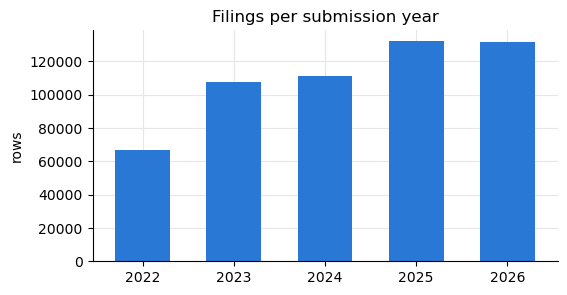

In [3]:
print("unique_id is unique:", df["unique_id"].is_unique)

per_year = df["submission_year"].value_counts().sort_index()
print(per_year)

ax = per_year.plot.bar(color=BLUE, width=0.6, figsize=(6, 3), rot=0)
ax.set_title("Filings per submission year"); ax.set_xlabel(""); ax.set_ylabel("rows")
plt.show()

**What to notice:**
- `unique_id` is unique, so it's a natural **primary key**.
- 2022 is smaller because only buildings with 10+ units had to report that year (smaller buildings started in 2023).
- There is **no unit ID that stays the same across years**. The same apartment filed in 2023 and 2024 gets two unrelated `unique_id`s,
  and addresses are blurred to the block. So we **can't follow one apartment over time**. That limits some queries.
- DataSF warns: to count units, pick a year and count ids. **Don't sum `unit_count`** (that's the whole building's size, repeated on every unit row).

## 3. The 28 columns, grouped by what they describe

Grouping columns by *what they're about* is the first step toward normalization.

In [4]:
groups = {
    "Filing (the submission itself)": ["unique_id", "case_type_name", "submission_year", "signature_date"],
    "Location":                       ["block_num", "block_address", "point", "analysis_neighborhood", "supervisor_district"],
    "Building":                       ["unit_count", "year_property_built"],
    "Unit":                           ["occupancy_type", "bedroom_count", "bathroom_count", "square_footage", "monthly_rent"],
    "Utilities included in rent":     ["base_rent_includes_water_sewer", "base_rent_includes_natural_gas",
                                       "base_rent_includes_electricity", "base_rent_includes_refuse_recycling",
                                       "base_rent_includes_other_utilities"],
    "Occupancy / vacancy timing":     ["occupancy_or_vacancy_date", "occupancy_or_vacancy_date_year", "vacancy_date",
                                       "past_occupancy", "occupancy_or_vacancy_date_history"],
    "DataSF export metadata":         ["data_as_of", "data_loaded_at"],
}
assert sum(len(v) for v in groups.values()) == 28

summary = pd.DataFrame([
    {"group": g, "column": c,
     "missing": df[c].isna().sum(),
     "% missing": round(df[c].isna().mean() * 100, 1),
     "distinct values": df[c].nunique(),
     "example": df[c].dropna().iloc[0] if df[c].notna().any() else None}
    for g, cols in groups.items() for c in cols
])
summary

,group,column,missing,% missing,distinct values,example
0,Filing (the submission itself),unique_id,0,0.0,549899,2394745219893176429
1,Filing (the submission itself),case_type_name,0,0.0,5,Housing Inventory - Unit information (2026)
2,Filing (the submission itself),submission_year,0,0.0,5,2026
3,Filing (the submission itself),signature_date,0,0.0,1534,2025/11/26
4,Location,block_num,6,0.0,4287,1804
5,Location,block_address,80,0.0,7676,1300 Block of LA PLAYA ST
6,Location,point,3,0.0,13368,POINT (-122.509404715 37.763084762)
7,Location,analysis_neighborhood,19,0.0,41,Sunset/Parkside
8,Location,supervisor_district,16,0.0,11,4
9,Building,unit_count,2,0.0,300,28


**What to notice:**
- **Mostly complete:** filing, location and unit columns.
- **Mostly empty:** `base_rent_includes_other_utilities` (~93%), `vacancy_date` (~96%), `occupancy_or_vacancy_date_history` (~85%).
  That's not an error. They only apply to *some* units (e.g. vacancy date only for vacant units).
- **Only 1 distinct value:** `data_as_of`, `data_loaded_at`. That's export metadata, not information about units, so **drop them**.

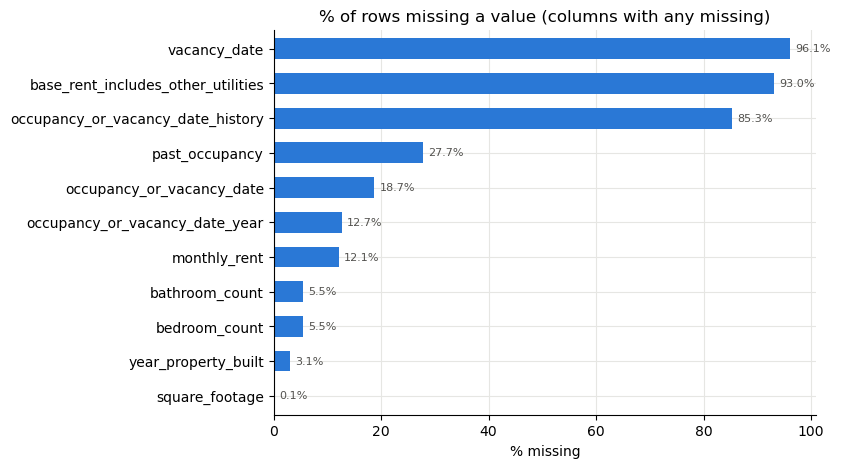

In [5]:
miss = summary.set_index("column")["% missing"].sort_values()
miss = miss[miss > 0]
ax = miss.plot.barh(color=BLUE, figsize=(7, 5), width=0.6)
ax.set_title("% of rows missing a value (columns with any missing)"); ax.set_xlabel("% missing"); ax.set_ylabel("")
for i, v in enumerate(miss):
    ax.text(v + 1, i, f"{v}%", va="center", fontsize=8, color="#52514e")
plt.show()

## 4. Redundant columns

A column is redundant if another column already tells you its value.

In [6]:
# Does each submission_year always come with the same case_type_name?
pd.crosstab(df["case_type_name"], df["submission_year"])

submission_year,2022,2023,2024,2025,2026
case_type_name,,,,,
Housing Inventory - Unit information (2022),66744,0,0,0,0
Housing Inventory - Unit information (2023),0,107886,0,0,0
Housing Inventory - Unit information (2024),0,0,111513,0,0
Housing Inventory - Unit information (2025),0,0,0,132088,0
Housing Inventory - Unit information (2026),0,0,0,0,131668


**What to notice:** every row sits on the diagonal. `case_type_name` is just `"Housing Inventory - Unit information (" + year + ")"`.
It's **fully determined by `submission_year`**, so storing both would repeat information. Drop it, or keep it in a tiny lookup table.

## 5. The unit columns are messy categories, not numbers

Owners typed these in, so the same thing is spelled many ways. Let's look at **every** value.

In [7]:
df['bedroom_count'].value_counts(dropna=False)

bedroom_count
One-Bedroom       208903
Studio            141277
Two-Bedroom       127291
NaN                30434
Three-Bedroom      30031
Four-Bedroom        6220
5+                  1605
1                   1569
2                    999
0                    605
One Bedroom          199
3                    163
Two Bedroom          145
studio               143
1 Bedroom             74
1 bedroom             41
1br                   38
3 bedroom             26
One-bedroom           18
2 bedroom             13
2br                   12
2A                    11
Garage                10
2S                     9
1A                     7
2brd                   6
Studio (sm)            6
2T                     5
2U                     5
3bedroom               4
1U                     4
Two-bedroom            4
1bedroom               3
0U                     3
Zero-(Studio)          2
1T                     2
Zero -(Studio)         2
Five-Bedroom           2
1 bed                  1
0A         

**What to notice:** 45 different spellings. `One-Bedroom`, `One Bedroom`, `1 Bedroom`, `1br`, `1`... all mean *1 bedroom*.
There's also junk: `Garage`, `Vacant`, `$D$61` (a spreadsheet cell reference!), and typos like `2 bedriin`.
**Cleaning step:** map each spelling to a number of bedrooms (Studio = 0), and flag values that can't be mapped.

In [8]:
df['bathroom_count'].value_counts(dropna=False)

bathroom_count
One bathroom                                   414847
Two bathrooms                                   60287
NaN                                             30340
Shared bathroom facilities with other units     21030
One and a half bathrooms                        10845
Three bathrooms or more                          4645
Two and a half bathrooms                         3889
1                                                2617
One Bathroom                                      529
2                                                 240
One-Bathroom                                      130
Two bathroom                                      124
0                                                  93
1.00                                               65
1 bathroom                                         64
2.5                                                52
2 bathroom                                         52
One-Bedroom                                        12
Two-Bathroom 

**What to notice:** same problem (30 spellings). Some are even **bedroom** answers typed into the bathroom column (`One-Bedroom`, `2 bedroom`).
`Shared bathroom facilities with other units` is a real category, not a number.

In [9]:
df['monthly_rent'].value_counts(dropna=False)

monthly_rent
NaN                                  66365
$2251-$2500                          41060
$1751-$2000                          40142
$2751-$3000                          38400
$2501-$2750                          36881
$2001-$2250                          36691
$1501-$1750                          36187
$1251-$1500                          31766
$3001-$3250                          29507
$3251-$3500                          27744
$1001-$1250                          26902
$751-$1000                           18755
$3501-$3750                          17994
$3751-$4000                          17049
$501-$750                            16576
$4001-$4250                          10933
$4251-$4500                          10159
$4751-$5000                           7088
$4501-$4750                           6533
$251-$500                             6061
$7000+                                4007
$5001-$5250                           3957
$5251-$5500                           359

**What to notice:** rent is **not a number**. It's a **$250-wide band** like `"$2251-$2500"`, and `"$7000+"` has no upper limit.
So we can't compute an exact average rent. We *can* split each band into `rent_min` and `rent_max` numbers and use the midpoint as an estimate.
`"$0 (no rent paid by the occupant)"` is a special case. There are also a few odd spellings (`0`, `$1750-$2000`, `$250-$500`).

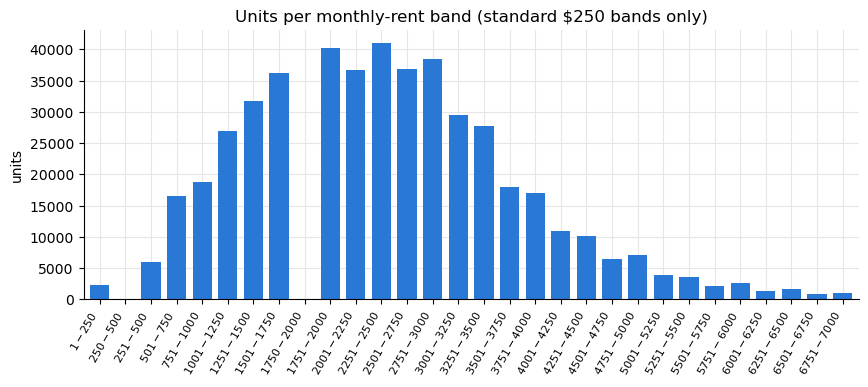

In [10]:
rent_order = (df["monthly_rent"].dropna()
              .loc[lambda s: s.str.match(r"^\$\d+-\$\d+$")]
              .value_counts())
rent_order = rent_order.sort_index(key=lambda idx: idx.str.extract(r"^\$(\d+)")[0].astype(int))
ax = rent_order.plot.bar(color=BLUE, width=0.75, figsize=(10, 3.5))
ax.set_title("Units per monthly-rent band (standard $250 bands only)"); ax.set_xlabel(""); ax.set_ylabel("units")
plt.xticks(rotation=60, ha="right", fontsize=8); plt.show()

In [11]:
df['square_footage'].value_counts(dropna=False)

square_footage
501-750 Sq.Ft      166661
751-1000 Sq.Ft     110944
251-500 Sq.Ft      109496
1001-1250 Sq.Ft     51458
Unknown             38398
0-250 Sq.Ft         34651
1251-1500 Sq.Ft     19584
1501-1750 Sq.Ft      9056
1751-2000 Sq.Ft      4047
2001-2250 Sq.Ft      1701
2251-2500 Sq.Ft      1515
2501-2750 Sq.Ft       537
2751-3000 Sq.Ft       534
NaN                   490
4000+ Sq.Ft           223
3001-3250 Sq.Ft       221
3251-3500 Sq.Ft       186
3501-3750 Sq.Ft       126
3751-4000 Sq.Ft        70
0-250 Sq.ft             1
Name: count, dtype: int64

**What to notice:** also banded (250 sq ft steps), plus `Unknown` and one lowercase `Sq.ft` variant.

In [12]:
df['occupancy_type'].value_counts()

occupancy_type
Occupied by non-owner    483297
Vacant                    36075
Occupied by owner         27901
Non-Residential            2626
Name: count, dtype: int64

**What to notice:** clean, just 4 values. About 88% of filings are tenant-occupied (*Occupied by non-owner*). About 6.6% are vacant.

## 6. Utilities: a *repeating group* (a 1NF problem)

Five columns ask the same question ("is utility X included in rent?") for different utilities.

In [13]:
util_cols = groups["Utilities included in rent"]
for c in util_cols[:4]:
    print(c, df[c].value_counts().to_dict())
print()
df["base_rent_includes_other_utilities"].value_counts().head(15)

base_rent_includes_water_sewer {'Y': 287325, 'N': 262574}
base_rent_includes_natural_gas {'N': 497671, 'Y': 52228}
base_rent_includes_electricity {'N': 518431, 'Y': 31468}
base_rent_includes_refuse_recycling {'Y': 289621, 'N': 260278}



base_rent_includes_other_utilities
heat                      16408
other                     11037
steam heat                 5678
wifi                        623
parking                     620
pest control                373
cable and internet          319
internet                    282
parking & heat              219
yes                         206
pest                        174
trash                       146
hot water                   138
all utilities included      138
non                         132
Name: count, dtype: int64

**What to notice:**
- Four of them are clean `Y`/`N` flags. The fifth is **free text** (`heat`, `steam heat`, `wifi`, `parking`...).
- Having `utility_1, utility_2, utility_3...` as columns is called a **repeating group**. It breaks the spirit of **1NF**:
  to add "internet" you'd have to add a column, and to ask "which utility is most often included?" you'd have to query 5 columns.
- **Fix:** a `utility` table (one row per utility type) plus a linking table `(unique_id, utility_id)` listing which utilities each filing includes.

## 7. Occupancy history: a *list stuffed into one cell* (a 1NF violation)

1NF says every cell holds **one atomic value**. This column holds a JSON **list** of date ranges.

In [14]:
example = df["occupancy_or_vacancy_date_history"].dropna()
print(example.iloc[0])
print("---")
lengths = example.map(lambda s: len(json.loads(s)))
print("entries per filing (for filings that have history):")
print(lengths.value_counts().sort_index())

[
  {
    "date_range_type": "Vacant",
    "start_date": "2022-10-02"
  }
]
---
entries per filing (for filings that have history):
occupancy_or_vacancy_date_history
1    80985
Name: count, dtype: int64


In [15]:
# "Explode" the list: one row per (filing, period). This is exactly what a 1NF fix looks like.
hist = (df.loc[df["occupancy_or_vacancy_date_history"].notna(), ["unique_id", "occupancy_or_vacancy_date_history"]]
          .assign(entry=lambda d: d["occupancy_or_vacancy_date_history"].map(json.loads))
          .explode("entry"))
hist = pd.concat([hist[["unique_id"]].reset_index(drop=True),
                  pd.json_normalize(hist["entry"].tolist())], axis=1)
print(f"{len(hist):,} history rows from {hist['unique_id'].nunique():,} filings")
hist.head(8)

80,985 history rows from 80,985 filings


,unique_id,date_range_type,start_date,end_date
0,3448753151243725482,Vacant,2022-10-02,NaN
1,3664142395147815712,Occupied,2021-06-30,2024-07-21
2,3921341163576885786,Vacant,2011-07-05,2023-09-11
3,2391388427570862092,Occupied,2016-07-18,2022-07-01
4,2817136686214808630,NaN,2019-07-17,2021-06-16
5,3255301782078878104,Occupied,2022-08-15,NaN
6,3953748950689918265,Occupied,2023-06-09,NaN
7,4208615782109731499,Occupied,2020-10-09,2022-10-22


**What to notice:**
- In this snapshot every list happens to hold **exactly one** period. It's still not atomic: one cell packs *three* facts (type, start date, end date) in JSON. And the format allows many periods, so the schema should too.
- The history becomes its own table `occupancy_history(unique_id, seq_no, date_range_type, start_date, end_date)`,
linked back to the filing by `unique_id` (a **foreign key**). Other team members also did this. It's the clearest 1NF example to show in the presentation.

## 8. Dates: bad values

In [16]:
for c in ["signature_date", "occupancy_or_vacancy_date", "vacancy_date"]:
    d = pd.to_datetime(df[c], format="%Y/%m/%d", errors="coerce")
    print(f"{c:28s} earliest={d.min().date()}  latest={d.max().date()}  "
          f"unparseable={(d.isna() & df[c].notna()).sum()}  before-1900={(d.dt.year < 1900).sum()}")

signature_date               earliest=1974-04-26  latest=2026-12-02  unparseable=134  before-1900=0
occupancy_or_vacancy_date    earliest=1899-12-30  latest=2109-09-01  unparseable=98  before-1900=23
vacancy_date                 earliest=1899-12-30  latest=2027-06-02  unparseable=72  before-1900=13


In [17]:
yr = df["occupancy_or_vacancy_date_year"]
num = pd.to_numeric(yr, errors="coerce")
print("Text values in the 'year' column:")
print(yr[num.isna() & yr.notna()].value_counts())
print("\nImpossible numeric years:", [int(x) for x in sorted(num[(num < 1900) | (num > 2026)].unique())])

Text values in the 'year' column:
occupancy_or_vacancy_date_year
Year Unknown (more than 20 years)          3587
Year unknown (no information available)    1848
Year Unknown (within past 10-20 years)     1840
Year Unknown (within past five years)      1314
Year Unknown (within past 5-10 years)       966
Name: count, dtype: int64

Impossible numeric years: [2, 3, 6, 18, 20, 21, 22, 84, 91, 121, 123, 124, 197, 199, 200, 201, 202, 204, 205, 206, 211, 214, 219, 221, 222, 225, 285, 987, 1012, 1022, 1025, 1079, 1899, 2027, 2028, 2029, 2035, 2068, 2069, 2077, 2109, 2519, 3020, 3022, 5020, 12023, 20005, 20022, 20201, 20204, 20205, 20211, 20217, 20220, 20222, 20252, 21994, 52022, 202023]


**What to notice:**
- Signature dates from **1974**, occupancy dates in **2109**, dates that can't be parsed at all (many are year `0001`, a typing error).
- The "year" column mixes real years with **text answers** like `Year Unknown (more than 20 years)`, and impossible years like `2` or `202023`.
- **Cleaning step:** keep valid dates, set invalid ones to NULL, and **record what was wrong** so nothing disappears silently.
  (Jun's `record_quality_flag` table does exactly this.)

## 9. Duplicates

In [18]:
dups = df.drop(columns=["unique_id"]).duplicated(keep=False)
print(f"{dups.sum():,} rows are identical to another row in every column except unique_id")

61,802 rows are identical to another row in every column except unique_id


**What to notice:** ~62k rows look like copies. But in a big building, two identical studios with the same rent band
*would* produce identical rows, because addresses are blurred to the block. So we **can't prove they're mistakes**.
Jun **tags** them instead of deleting them. That's a good point to explain if asked.

## 10. Which columns determine which? (hints for 2NF / 3NF)

A **functional dependency** `A → B` means: *if you know A, you know B.*
Check: group by A and count how many different B values each A has. If it's always 1, then A → B holds.

This is how we decide which columns can move into their own table.

In [19]:
def fd_check(a, b):
    sub = df.dropna(subset=[a, b])
    n_b = sub.groupby(a)[b].nunique()
    return {"A": a, "B": b, "A values": len(n_b),
            "% of A values with >1 B": round((n_b > 1).mean() * 100, 1)}

pd.DataFrame([
    fd_check("point", "analysis_neighborhood"),
    fd_check("point", "supervisor_district"),
    fd_check("block_address", "analysis_neighborhood"),
    fd_check("block_address", "point"),
    fd_check("block_num", "block_address"),
    fd_check("block_address", "year_property_built"),
    fd_check("block_address", "unit_count"),
    fd_check("analysis_neighborhood", "supervisor_district"),
    fd_check("submission_year", "case_type_name"),
])

,A,B,A values,% of A values with >1 B
0,point,analysis_neighborhood,13363,0.0
1,point,supervisor_district,13364,0.0
2,block_address,analysis_neighborhood,7671,2.9
3,block_address,point,7675,61.0
4,block_num,block_address,4287,83.7
5,block_address,year_property_built,7652,71.5
6,block_address,unit_count,7676,70.0
7,analysis_neighborhood,supervisor_district,41,58.5
8,submission_year,case_type_name,5,0.0


**How to read this:** 0% means the dependency holds perfectly. Anything above that means it doesn't.

**What to notice:**
- `point → neighborhood` and `point → supervisor_district` hold **perfectly (0%)**.
  So in the flat table we have `unique_id → point → neighborhood`, a **transitive dependency**, which is exactly what **3NF** removes.
  Fix: a `location_point(point_id, lat, lon, neighborhood_id, district_id)` table. Both Jun and Andrei moved location out; compare *how*.
- `block_address → year_property_built / unit_count` **fail badly (~70%)**, because a "block" contains many different buildings.
  So there's **no reliable "building" entity**, and building facts must stay on each filing row.
  (Shraddha's note in the chat found the same thing.) This is a good Q&A answer for *"why no Property table?"*
- `neighborhood → district` fails (neighborhoods cross district lines), so those two can't be merged into one chain.
- `submission_year → case_type_name` holds (0%), which confirms section 4.

## 11. Summary: the "mess list" (use this on the *Dataset complexity* slide)

| Problem | Columns | Normal-form / cleaning issue | Fix |
|---|---|---|---|
| List inside one cell | `occupancy_or_vacancy_date_history` | violates **1NF** | `occupancy_history` child table |
| Repeating group | 5 × `base_rent_includes_*` | **1NF** (repeating group) | `utility` + linking table |
| Transitive dependency | `point → neighborhood, district` | violates **3NF** | `location_point` table |
| Redundant column | `case_type_name` (from year) | redundancy | drop / lookup |
| Constant columns | `data_as_of`, `data_loaded_at` | not unit data | drop |
| Many spellings | `bedroom_count` (45), `bathroom_count` (30) | dirty categories | map to numbers + flag junk |
| Banded numbers | `monthly_rent`, `square_footage` | text, not numeric | parse into min / max |
| Invalid dates | signature 1974, occupancy 2109, year `0001` | domain errors | NULL + quality flag |
| Mixed text in a year column | `occupancy_or_vacancy_date_year` | domain errors | split year vs "unknown reason" |
| Look-alike rows | ~62k | can't prove duplicate | tag, don't delete |
| No stable unit ID across years | whole dataset | limits over-time analysis | analyze by year / area |

**Next notebook:** `02` walks through 1NF → 2NF → 3NF step by step using these findings.